In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
sub_experiments = ['background', 'target', 'target_polarity']

path = '../../results/remote/'

data = pd.DataFrame()

for test in sub_experiments:
    
    df = pd.read_csv(f'{path}results_{test}/movement_rate_metrics.csv')
    df['study'] = test
    data = pd.concat([data, df])
    data = data.reset_index(drop = True)
    
data['study_condition'] = [f'{data.condition[idx]}_{data.study[idx]}' for idx in data.index]
data['abs_magnitude'] = np.abs(data.magnitude)

In [17]:
data[data.study == 'target']

,condition,minimum,latency,baseline,magnitude,flash_shown,stim_jumped,prolific_id,study,study_condition,abs_magnitude
80,flash+ jump+,0.543142,412,1.0,-0.456858,1,1,58acbfacea3d11000170e99a,target,flash+ jump+_target,0.456858
81,flash+ jump-,0.724664,419,1.0,-0.275336,1,0,58acbfacea3d11000170e99a,target,flash+ jump-_target,0.275336
82,flash- jump+,0.520254,437,1.0,-0.479746,0,1,58acbfacea3d11000170e99a,target,flash- jump+_target,0.479746
83,flash- jump-,0.743335,626,1.0,-0.256665,0,0,58acbfacea3d11000170e99a,target,flash- jump-_target,0.256665
84,flash+ jump+,0.676589,544,1.0,-0.323411,1,1,5c2279c061685000011d9d5b,target,flash+ jump+_target,0.323411
...,...,...,...,...,...,...,...,...,...,...,...
155,flash- jump-,1.076209,398,1.0,0.076209,0,0,611d580c8ca031dceaf5bce5,target,flash- jump-_target,0.076209
156,flash+ jump+,0.694606,412,1.0,-0.305394,1,1,6155cbd24be7bcccea214120,target,flash+ jump+_target,0.305394
157,flash+ jump-,0.750305,309,1.0,-0.249695,1,0,6155cbd24be7bcccea214120,target,flash+ jump-_target,0.249695
158,flash- jump+,0.634307,423,1.0,-0.365693,0,1,6155cbd24be7bcccea214120,target,flash- jump+_target,0.365693


In [21]:
def make_metric_for_all_studies_plot(data, x_axis, metric, 
                                     facecolors, edgecolors, barcolors, 
                                     studies, conditions, figsize, save_path,
                                     show_null = False):
    fig, axs = plt.subplots(1, 1, figsize = figsize)
    if show_null:
        axs.hlines(0, 0, 13, color = 'grey', zorder = -3)
    pos = 0
    for study in studies:
        study_data = data[data.study == study]
        for condition in conditions:
            a = sns.stripplot(data=study_data[study_data.condition.isin([condition])],
                              x = pos,
                              y = metric,
                              hue = x_axis,
                              palette = facecolors,
                              linewidth = 1,
                              edgecolor = edgecolors[f'{condition}_{study}'],
                              legend = False,
                              ax = axs,
                              alpha = 0.5,
                              zorder = -2)

            axs.vlines(pos, 
                       study_data[study_data.condition.isin([condition])][metric].mean()-study_data[study_data.condition.isin([condition])][metric].sem(),
                       study_data[study_data.condition.isin([condition])][metric].mean()+study_data[study_data.condition.isin([condition])][metric].sem(),
                       color = barcolors[f'{condition}_{study}'], zorder = -1)

            axs.scatter(pos, study_data[study_data.condition.isin([condition])][metric].mean(),
                        facecolor = facecolors[f'{condition}_{study}'], 
                        edgecolor = edgecolors[f'{condition}_{study}'], 
                        s = 20,
                       linewidth = 2,
                       zorder = 1)

            pos+=1
        a = sns.stripplot(data=study_data[study_data.condition.isin([condition])],
                        x = pos,
                    y = metric,
                    legend = False,
                    ax = axs,
                    alpha = 0,
                    zorder = -2)

        pos+=1

    plt.xticks([]);
    plt.savefig(save_path)
    plt.show()

In [19]:
barcolors = {'flash+ jump+_background': '#3DA7B8',
              'flash+ jump+_target': '#C73E1D',
              'flash+ jump+_target_polarity': '#FFC759', 
              'flash+ jump-_background': '#3DA7B8',
              'flash+ jump-_target':'#C73E1D', 
              'flash+ jump-_target_polarity': '#FFC759',
              'flash- jump+_background': 'black', 
              'flash- jump+_target': 'black',
              'flash- jump+_target_polarity': 'black', 
              'flash- jump-_background': 'black',
              'flash- jump-_target': 'black', 
              'flash- jump-_target_polarity':'black' 
}

facecolors = {'flash+ jump+_background': '#3DA7B8',
              'flash+ jump+_target': '#C73E1D',
              'flash+ jump+_target_polarity': '#FFC759', 
              'flash+ jump-_background': 'white',
              'flash+ jump-_target':'white', 
              'flash+ jump-_target_polarity': 'white',
              'flash- jump+_background': 'black', 
              'flash- jump+_target': 'black',
              'flash- jump+_target_polarity': 'black', 
              'flash- jump-_background': 'white',
              'flash- jump-_target': 'white', 
              'flash- jump-_target_polarity':'white' 
}

edgecolors = {'flash+ jump+_background': None,
              'flash+ jump+_target': None,
              'flash+ jump+_target_polarity': None, 
              'flash+ jump-_background': '#3DA7B8',
              'flash+ jump-_target':'#C73E1D', 
              'flash+ jump-_target_polarity': '#FFC759',
              'flash- jump+_background': None, 
              'flash- jump+_target': None,
              'flash- jump+_target_polarity': None, 
              'flash- jump-_background': 'black',
              'flash- jump-_target': 'black', 
              'flash- jump-_target_polarity':'black' 
}

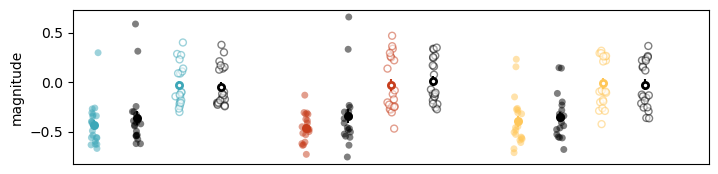

In [22]:
metric = 'magnitude'
studies = sub_experiments
conditions = ['flash+ jump+', 'flash- jump+', 'flash+ jump-', 'flash- jump-']
save_path = '../../results/all_magnitudes_combined.svg'
x_axis = 'study_condition'
figsize = (8.2, 2)


make_metric_for_all_studies_plot(data, x_axis, metric, 
                                 facecolors, edgecolors, barcolors, 
                                 studies, conditions, 
                                 figsize, save_path, show_null = False)

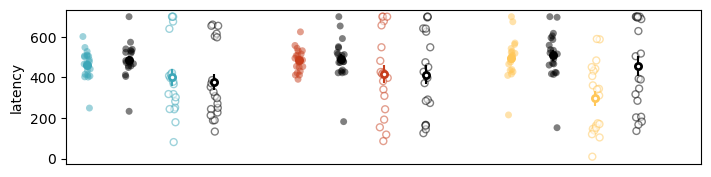

In [23]:
metric = 'latency'
save_path = '../../results/all_latencies_combined.svg'

make_metric_for_all_studies_plot(data, x_axis, metric, 
                                 facecolors, edgecolors, barcolors, 
                                 studies, conditions, 
                                 figsize, save_path)

In [38]:
grouped_data_jump = data.groupby(['study', 'stim_jumped', 'prolific_id']).mean(numeric_only = True).reset_index()
grouped_data_flash = data.groupby(['study', 'flash_shown', 'prolific_id']).mean(numeric_only = True).reset_index()

In [39]:
print(f"Study and Stim Jumped - Magnitude")

mag_data = grouped_data_jump.groupby(['study', 'stim_jumped']).describe()['magnitude']
mag_data['SEM'] = mag_data['std']/np.sqrt(mag_data['count'])
mag_data

Study and condition - Magnitude


count      mean       std       min       25%  \
study           stim_jumped                                                  
background      0             20.0 -0.036389  0.180019 -0.252959 -0.182581   
                1             20.0 -0.394796  0.223602 -0.643517 -0.547142   
target          0             20.0 -0.004406  0.232650 -0.369933 -0.198839   
                1             20.0 -0.399662  0.184425 -0.740293 -0.525758   
target_polarity 0             20.0 -0.016791  0.203760 -0.391024 -0.171970   
                1             20.0 -0.370187  0.224695 -0.693933 -0.531656   

                                  50%       75%       max       SEM  
study           stim_jumped                                          
background      0           -0.078641  0.093013  0.331622  0.040253  
                1           -0.404363 -0.337315  0.305717  0.049999  
target          0           -0.010285  0.249341  0.403646  0.052022  
                1           -0.414544 -0.333088  0.013896  0.041239  
target_polarity 0           -0.019810  0.104180  0.330269  0.045562  
                1           -0.431311 -0.285109  0.187299  0.050243

In [40]:
print(f"Study and Flash Shown - Magnitude")
mag_data = grouped_data_flash.groupby(['study', 'flash_shown']).describe()['magnitude']
mag_data['SEM'] = mag_data['std']/np.sqrt(mag_data['count'])
mag_data

Study and Flash Shown - Magnitude


count      mean       std       min       25%  \
study           flash_shown                                                  
background      0             20.0 -0.201348  0.200316 -0.431057 -0.372616   
                1             20.0 -0.229837  0.183316 -0.462467 -0.334624   
target          0             20.0 -0.161780  0.205245 -0.513171 -0.305803   
                1             20.0 -0.242289  0.180122 -0.597056 -0.371935   
target_polarity 0             20.0 -0.185466  0.187779 -0.518894 -0.332086   
                1             20.0 -0.201512  0.205202 -0.566062 -0.352896   

                                  50%       75%       max       SEM  
study           flash_shown                                          
background      0           -0.231239 -0.125909  0.345479  0.044792  
                1           -0.295317 -0.107303  0.291860  0.040991  
target          0           -0.164613 -0.076758  0.335417  0.045894  
                1           -0.270413 -0.098533  0.028411  0.040277  
target_polarity 0           -0.225216 -0.055796  0.254364  0.041989  
                1           -0.198869 -0.085642  0.263204  0.045885

In [42]:
print(f"Study and Stim Jumped - Latency")
mag_data = grouped_data_jump.groupby(['study', 'stim_jumped']).describe()['latency']
mag_data['SEM'] = mag_data['std']/np.sqrt(mag_data['count'])
mag_data

Study and Flash Shown - Latency


count     mean         std    min     25%  \
study           stim_jumped                                              
background      0             20.0  389.375  149.667515  147.0  265.75   
                1             20.0  475.325   73.065629  241.0  448.00   
target          0             20.0  416.625  175.329230  126.0  264.00   
                1             20.0  488.075   65.108669  357.0  436.00   
target_polarity 0             20.0  377.150  125.548596  141.0  298.25   
                1             20.0  502.425  105.319223  183.5  448.75   

                                50%      75%    max        SEM  
study           stim_jumped                                     
background      0            366.50  511.875  647.5  33.466674  
                1            478.75  522.375  588.0  16.337971  
target          0            476.00  537.750  700.0  39.204808  
                1            492.25  522.750  662.5  14.558741  
target_polarity 0            398.75  432.000  645.0  28.073520  
                1            506.25  564.625  686.0  23.550094

In [43]:
print(f"Study and Flash Shown - Latency")
mag_data = grouped_data_flash.groupby(['study', 'flash_shown']).describe()['latency']
mag_data['SEM'] = mag_data['std']/np.sqrt(mag_data['count'])
mag_data

Study and Stim Jumped - Latency


count     mean         std    min      25%  \
study           flash_shown                                               
background      0             20.0  432.150  109.738697  241.5  355.750   
                1             20.0  432.550  104.086869  241.5  377.750   
target          0             20.0  452.850  124.569797  153.5  383.750   
                1             20.0  451.850   90.816052  308.5  365.000   
target_polarity 0             20.0  483.800  110.277449  315.5  402.875   
                1             20.0  395.775   76.781555  250.5  333.000   

                                50%      75%    max        SEM  
study           flash_shown                                     
background      0            417.25  546.625  591.0  24.538319  
                1            420.00  479.250  612.0  23.274531  
target          0            453.25  541.875  621.5  27.854653  
                1            437.50  534.875  595.5  20.307087  
target_polarity 0            476.25  566.875  656.5  24.658787  
                1            407.25  447.250  513.5  17.168878

### Get the movement rate values at the cluster center

In [45]:
sub_experiments = ['background', 'target', 'target_polarity']

path = '../../results/remote/'

data = pd.DataFrame()

for test in sub_experiments:
    
    df = pd.read_csv(f'{path}results_{test}/movement_rate_clusters.csv')
    df['study'] = test
    data = pd.concat([data, df])
    data = data.reset_index(drop = True)
    
data['study_condition'] = [f'{data.condition[idx]}_{data.study[idx]}' for idx in data.index]
data = data[abs(data.cluster_weight) > data.weight_cutoff]
data = data[data.center_value < 1]
data = data[data.condition == 'flash+ jump-']
data

,condition,location,start_time,end_time,center_location,center_value,center_location_idx,cluster_weight,weight_cutoff,SEM,study,study_condition
1,flash+ jump-,[1019 1020 1021 1022 1023 1024 1025 1026 1027 ...,319,486,405,0.929138,1105,-535.270780,221.987416,0.026575,background,flash+ jump-_background
23,flash+ jump-,[1004 1005 1006 1007 1008 1009 1010 1011 1012 ...,304,479,388,0.907546,1088,-661.179192,230.416408,0.038527,target,flash+ jump-_target


#### get mean movement rate per participant between 304 ms and 486 ms

In [46]:
np.mean(data.center_location)

396.5

In [ ]:
sub_experiments = ['target_polarity', 'background', 'target']

path = '../../results/remote/'
data = pd.DataFrame(columns = ['study', 'participant', 'rate_mean'])
r = 0
for test in sub_experiments:
    df = pd.read_csv(f'{path}results_{test}/movement_rates_flash_only.csv')
    for p in df.index:
        data.loc[r, 'study'] = test
        data.loc[r, 'participant'] = p
        data.loc[r, 'rate_mean'] = np.mean(df.loc[p][1097])
        r+=1

In [ ]:
fig, axs = plt.subplots(1,1, figsize = (5,3))
r = 0
for test in sub_experiments:
    sns.stripplot(data = data[data.study == test],
                  x = r,
                  y = 'rate_mean',
                  hue = 'study',
                  ax = axs,
                  linewidth = 2,
                  s = 3,
                  edgecolor =  {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test],
                  palette = {'background': 'white', 'target': 'white', 'target_polarity': 'white'},
                  legend = False,
                  alpha = 0.5,
                 zorder = -2)
    
    axs.scatter(r, data[data.study == test]['rate_mean'].mean(),
                facecolor = {'background': 'white', 'target': 'white', 'target_polarity': 'white'}[test],
                edgecolor = {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test], 
                s = 40,
                linewidth = 3,
                zorder = 1)
    
    axs.vlines(r, 
               data[data.study == test]['rate_mean'].mean()-data[data.study == test]['rate_mean'].sem(),
               data[data.study == test]['rate_mean'].mean()+data[data.study == test]['rate_mean'].sem(),
               color = {'background': '#3DA7B8', 'target': '#C73E1D', 'target_polarity': '#FFC759'}[test], zorder = -1)
    
    r+=1

axs.hlines(1, -0.5, 2.5, color = 'black');
fig.savefig(f'{path}movement_rates_at_cluster_center.svg');